In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.integrate import trapezoid

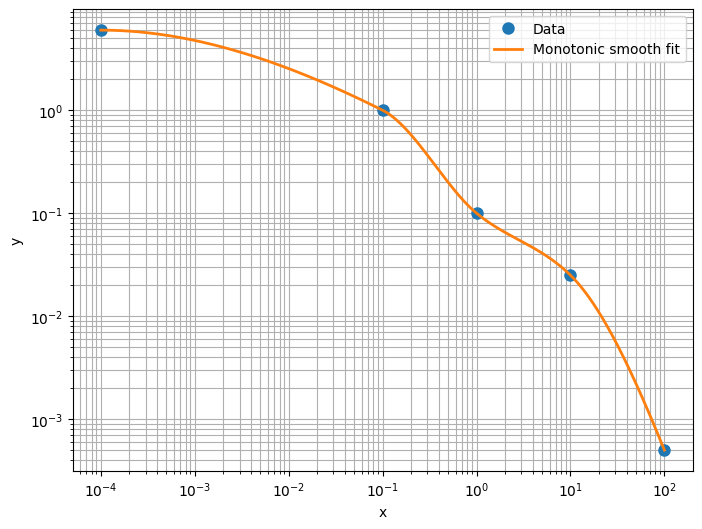

In [2]:
#Electron density in galaxy (milky way), from Yao, Manchester, Wang , https://arxiv.org/pdf/1610.09448

x = np.array([1e-4, 1e-1, 1, 1e1, 1e2])#kpc
y = np.array([6, 1, 0.1, 2.5e-2, 5e-4])

# interpolate in log-log space
logx = np.log10(x)
logy = np.log10(y)

interp = PchipInterpolator(logx, logy)
#PCHIP stands for Piecewise Cubic Hermite Interpolating Polynomial.

xfit = np.logspace(logx.min(), logx.max(), 2000)
yfit = 10**interp(np.log10(xfit))
plt.figure(figsize=(8,6))
plt.loglog(x, y, 'o', ms=8, label='Data')
plt.loglog(xfit, yfit, lw=2, label='Monotonic smooth fit')

plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, which='both')
plt.legend()
plt.show()

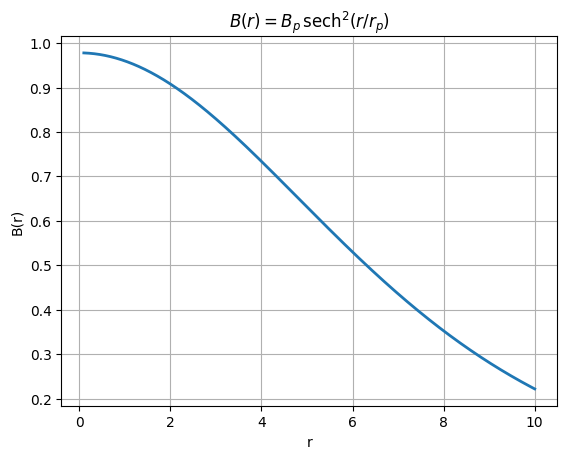

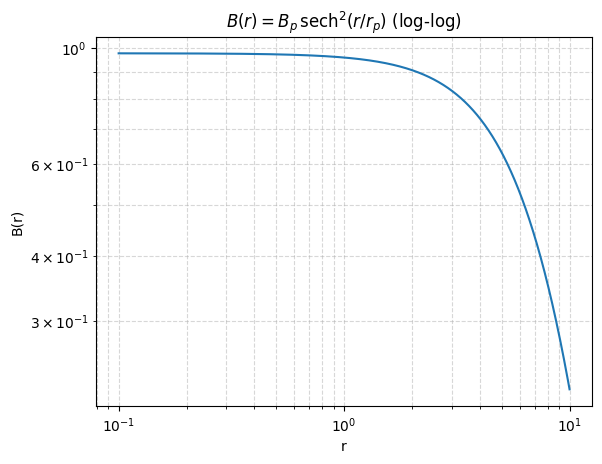

In [5]:
#For the B_parallel, from https://arxiv.org/pdf/2311.12120
#sech2 plot 

# ---- fill these ----
Bp = 0.978 #+-0.033 #muG   # peak magnetic field
rp = 7.29  #+- 0.06 #kpc  # scale radius
# --------------------

r = np.logspace(-1,1, 5000) #kpc

B = Bp * (1 / np.cosh(r / rp))**2   # sech^2(x) = 1/cosh^2(x)

plt.plot(r, B, lw=2)
plt.xlabel("r")
plt.ylabel("B(r)")
plt.title(r"$B(r) = B_p \, \mathrm{sech}^2(r/r_p)$")
plt.grid(True)
plt.show()



#loglog
plt.loglog(r, B)

plt.xlabel("r")
plt.ylabel("B(r)")
plt.title(r"$B(r) = B_p \, \mathrm{sech}^2(r/r_p)$ (log-log)")
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

Impact parameter b = 0.0 kpc
RM = 0.6157 rad/m^2


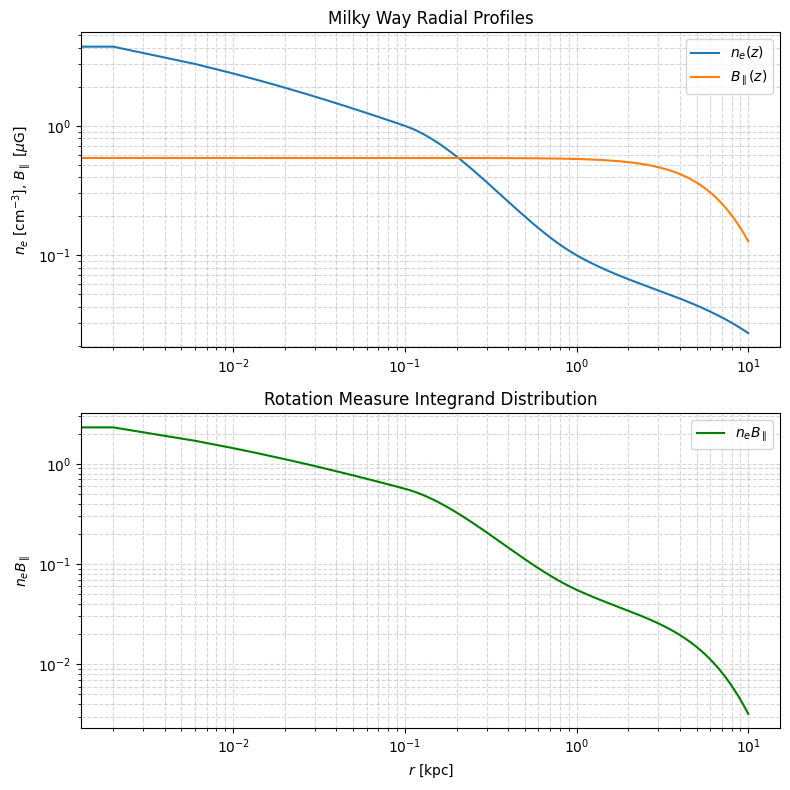

In [7]:
#Rotation measure 

b = 0.0   # kpc
x_data = np.array([1e-4, 1e-1, 1, 1e1, 1e2])      # kpc
y_data = np.array([6, 1, 0.1, 2.5e-2, 5e-4])      # cm^-3

logx = np.log10(x_data)
logy = np.log10(y_data)

ne_interp = PchipInterpolator(logx, logy)


Bp = 0.978   # microGauss
rp = 7.29    # kpc


# LOS component
def B_parallel(r):
    return (Bp / np.cosh(r / rp)**2) / np.sqrt(3)

#LOS 

L_max = 10  # kpc
N_z = 5000
z = np.linspace(-L_max, L_max, N_z)

r = np.sqrt(b**2 + z**2)

# avoid r=0
r = np.maximum(r, 1e-6)


ne = 10**ne_interp(np.log10(r))     # cm^-3
B  =                   # microGauss

integrand = ne * 
RM = 0.812 * trapezoid(integrand, z)

# # Faraday rotation angle (fixed frequency)
# nu = 54e6
# c = 3e8
# lambda_sq = (c / nu)**2

# FR_0 = lambda_sq * RM

#Output 

print(f"Impact parameter b = {b} kpc")
print(f"RM = {RM:.4f} rad/m^2")

#Plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8))

ax1.loglog(z, ne, label=r'$n_e(z)$')
ax1.loglog(z, B, label=r'$B_\parallel(z)$')
ax1.set_ylabel(r'$n_e$ [cm$^{-3}$], $B_\parallel$ [$\mu$G]')
ax1.grid(True, which='both', ls='--', alpha=0.5)
ax1.set_title(r'Milky Way Radial Profiles', fontsize=12)

ax1.legend()
ax2.loglog(z, integrand, color='green', label=r'$n_e B_\parallel$')

ax2.set_xlabel(r'$r$ [kpc]')
ax2.set_ylabel(r'$n_e B_\parallel$')
ax2.grid(True, which='both', ls='--', alpha=0.5)
ax2.set_title(r'Rotation Measure Integrand Distribution', fontsize=12)

ax2.legend()
plt.tight_layout()
plt.show()